In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
from torchvision.datasets import CIFAR10

In [2]:
#Datasets and Dataloaders
from torch.utils.data import DataLoader
import torchvision.transforms as transforms


transform = transforms.Compose([
    transforms.ToTensor(),# convert images to tensor and normalize(scale) the pixel values to [0, 1]
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # normalize the pixel values to [-1, 1],3 mean and 3 std for 3 channels (RGB)
])

train_dataset = CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = CIFAR10(root='./data', train=False, download=True, transform=transform)

In [3]:
train_dataset

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
           )

In [4]:
test_dataset

Dataset CIFAR10
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
           )

In [5]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)#batch size of 64 cause this is bigger dataset than ANN we used before.
test_loader = DataLoader(test_dataset, batch_size=64)

In [6]:
#Building the CNN model
class CNN(nn.Module):
    def __init__(self):
        super(CNN,self) .__init__()

        #Convolutional layers(convo layers+pulling layers stacked together)
        self.conv_layers=nn.Sequential(
            #1st convolutional layer
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3,padding=1),#input channels=3 cause RGB images, output channels=32 cause we want 32 feature maps, kernel size=3x3, padding=1 to keep the same size of the image after convolution,Convo2d cretes a 2d convolutional layer as it takes 2d images(32×32) aas input 
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            #2nd convolutional layer
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            #3rd convolutional layer
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3,padding=1),    
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)  
        )

        #Fully connected layers(layers becuase inside there are multiple layers like hidden layer,output layer etc.)
        self.fc_layers=nn.Sequential(
            nn.Linear(128*4*4, 256),#input features=128*4*4 cause after 3 pooling layers the image size is reduced to 4x4 and we have 128 feature maps, output features=256 cause we want 256 neurons in the hidden layer
            nn.ReLU(),
            nn.Linear(256, 10) #input features=256 cause we have 256 neurons in the hidden layer, output features=10 cause we have 10 classes in CIFAR-10 dataset
        )
    def forward(self, x):
        x=self.conv_layers(x)#at first we pass the input through the convolutional layers
        #now we need to flatten the output of the convolutional layers to pass it to the fully connected layers
        x=x.view(x.size(0), -1)#flatten the output of the convolutional layers, x.size(0) is the batch size, -1 means that we want to flatten the rest of the dimensions
        x=self.fc_layers(x)#now we pass the flattened output to the fully connected layers

        return x


In [7]:
model=CNN()

In [8]:
criterion=nn.CrossEntropyLoss()#loss function for multi-class classification
optimizer=optim.Adam(model.parameters())

In [9]:
img,lbl =train_dataset[0]#get the first image and label from the training dataset
print(lbl)#print the label of the first image

6


In [38]:
#so in train_datase and test_datset we have images and labels(class name in numbers 0-9) and we can get the class names from the training dataset using the classes attribute of the dataset
class_names = train_dataset.classes#get the class names from the training dataset
class_names

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [40]:
#Training the model
epochs=10

for epoch in range(epochs):
    model.train()#set the model to training mode
    running_loss=0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs=model(images) #Forward propagation
        loss=criterion(outputs, labels) #Calculate the loss
        loss.backward() #Backward propagation
        optimizer.step() #Update the weights
        running_loss += loss.item()
    train_loss = running_loss/len(train_loader) #average loss for the epoch per batch
    print(f"epoch={epoch+1}/epochs, train_loss={train_loss}")

c:\Users\deyar\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\autograd\graph.py:979: UserWarning: The detected GPU (Intel(R) Iris(R) Xe Graphics) is not officially supported by PyTorch XPU. Running workloads on this device may result in unexpected behavior.
For stable and fully supported execution, please use GPUs based on Intel Arc (Alchemist) series or newer.
Refer to the hardware prerequisites for more information: https://github.com/pytorch/pytorch/blob/main/docs/source/notes/get_start_xpu.rst#hardware-prerequisite (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\c10\xpu\XPUFunctions.cpp:138.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


epoch=1/epochs, train_loss=1.370895200601929
epoch=2/epochs, train_loss=0.9283289685273719
epoch=3/epochs, train_loss=0.7436315488556157
epoch=4/epochs, train_loss=0.6197619189310561
epoch=5/epochs, train_loss=0.5220730402280608
epoch=6/epochs, train_loss=0.43183416945626363
epoch=7/epochs, train_loss=0.3494936487616023
epoch=8/epochs, train_loss=0.2788763436133904
epoch=9/epochs, train_loss=0.21660189905091928
epoch=10/epochs, train_loss=0.16984250144008786


In [41]:
#now i will save the 10th epoch parameters, so that i can use it later to test the model without training it again
torch.save(model.state_dict(), 'cnn_model.pth')#save the model parameters to a file named cnn_model.pth in the current directory


In [10]:
model.load_state_dict(torch.load('cnn_model.pth'))#load the model parameters from the file cnn_model.pth
#next time we can skip the training cell,saving the model parameters cell and test the model without training it again, we can also use this file to load the model parameters in another script and use it for inference

<All keys matched successfully>

In [11]:
#always last epoch parameters are saved in the model so we can use it for evaluation and testing
#but if we want to save the best model parameters we can use validation dataset and save the best model parameters based on the validation loss(we done it in the ann regression model)
#Evaluating the model
#as it is a classification problem we will use accuracy as the evaluation metric
model.eval() #set the model to evaluation mode
correct=0
total=0
with torch.no_grad(): 
    for images, labels in test_loader:
        outputs=model(images) #Forward propagation
        _, predicted=torch.max(outputs.data, 1)
        total += labels.size(0) #total number of labels
        correct += (predicted == labels).sum().item() #number of correct predictions
    accuracy = 100 * correct / total
    print(f'Accuracy of the model on the {total} test images: {accuracy}%')


Accuracy of the model on the 10000 test images: 76.25%


Predicted Class: 4 (deer)
Confidence: 98.58%


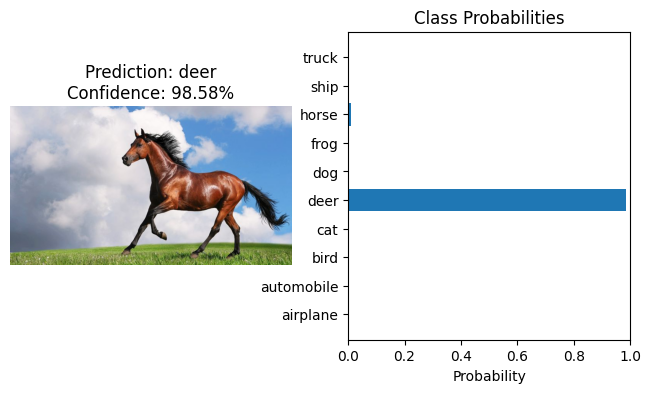

In [ ]:
#test the model on a single image, we have to preprocess the image in the same way as we did for the training and testing datasets, then we can pass it to the model and get the prediction
import torch
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Define the same transform used during training
transform = transforms.Compose([
    transforms.Resize((32, 32)),  # Ensure 32x32
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Define classes
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
           'dog', 'frog', 'horse', 'ship', 'truck']


image_path = 'demoimg1.jpg' 

# Load and preprocess
image = Image.open(image_path).convert('RGB')  # Convert to RGB
image_tensor = transform(image).unsqueeze(0)   # Add batch dimension

# Set model to evaluation mode
model.eval()

# Make prediction
with torch.no_grad():
    outputs = model(image_tensor)
    probabilities = torch.nn.functional.softmax(outputs, dim=1)
    predicted_class = torch.argmax(outputs, dim=1)

# Get results
class_index = predicted_class.item()
class_name = classes[class_index]
confidence = probabilities[0][class_index].item() * 100

# Display the image with prediction
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title(f"Prediction: {class_name}\nConfidence: {confidence:.2f}%")
plt.axis('off')


plt.subplot(1, 2, 2)
plt.barh(classes, probabilities[0].detach().numpy())
plt.title("Class Probabilities")
plt.xlabel("Probability")
plt.xlim(0, 1)

print(f"Predicted Class: {class_index} ({class_name})")
print(f"Confidence: {confidence:.2f}%")
